In [1]:
'''
Jane Jan, 2026
calculate the colinearity including the action category rdm

reference code: ppl_rdm.ipynb

tmux
conda activate action-python3
'''

'\nJane Jan, 2026\ncalculate the colinearity including the action category rdm\n\nreference code: ppl_rdm.ipynb\n'

In [2]:
# Import Environment
import numpy as np
import itertools

import os
from os.path import join

from glob import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata
from scipy.stats import zscore

# Directories
rdm_dir = '/backup/data/social_actions/scripts/RDMs'
ha_dir = '/backup/data/social_actions/scripts/post_hha'

In [3]:
# Load in target/model RDMs
# 5_ROI_RSA_python3-v2.py

motion_rdm = np.load(join(rdm_dir, 'pymoten_motion_energy_rdm.npy'))
gaze_rdm = np.load(join(rdm_dir, 'gaze_rdm.npy'))
verb_rdm = np.load(join(rdm_dir, 'verb_rdm.npy'))
nonverb_rdm = np.load(join(rdm_dir, 'nonverb_rdm.npy'))
object_rdm = np.load(join(rdm_dir, 'object_rdm.npy'))
social_rdm = np.load(join(rdm_dir, 'social_rdm.npy'))

static_object_rdm = np.load(join(rdm_dir, 'frame_arrangement_object_RDM.npy'))
static_scene_rdm = np.load(join(rdm_dir, 'frame_arrangement_scene_RDM.npy'))
static_person_rdm = np.load(join(rdm_dir, 'frame_arrangement_person_RDM.npy'))

# load bodypart rdm 
anno_rdm = np.load(join(rdm_dir, '../bodypart_rdm_JasonDazea.npy'))
#rdm_col_z = np.load(join(rdm_dir, '../Jason_bodypart_rdm_zscored_col.npy'))
ppl_rdm = np.load(join(rdm_dir, 'ppl_rdm.npy'))
actioncat_rdm = np.load(join(rdm_dir, 'action_category_rdm.npy'))
#sns_rdm = np.load(join(rdm_dir, 'social_nonsocial_rdm.npy'))

In [8]:
'''
# add action-category RDM (0 = same category, 1 = different category) 
condition_order = np.load("../condition_order.npy", allow_pickle=True).tolist()
cond = condition_order['original_condition_order']
cond = np.array([c.decode('utf-8') if isinstance(c, (bytes, bytearray)) else str(c) for c in cond])

cat = np.array([c.rsplit('_', 1)[0] for c in cond])          # e.g., "arts_crafts"
_, cat_id = np.unique(cat, return_inverse=True)              # int code per category

actioncat_rdm = pdist(cat_id[:, None], metric='hamming')     # condensed vector, values are 0/1

# save action category rdm 
np.save(join(rdm_dir, "action_category_rdm.npy"), actioncat_rdm)
'''

In [ ]:
'''
# add social non social rdm
import numpy as np
from scipy.spatial.distance import pdist, squareform

N = len(reorder)          # should be 90
assert N == 90

# class labels in reordered space: 0 for first half, 1 for second half
group_re = np.zeros(N, dtype=int)
group_re[45:] = 1

# map back to original order (because your model rdms are in original_condition_order space)
group_orig = np.empty(N, dtype=int)
group_orig[reorder] = group_re

# condensed binary RDM: 0 within-group, 1 across-group
sns_rdm = pdist(group_orig[:, None], metric="hamming")   # values are 0 or 1

# save social nonsocial rdm
np.save(join(rdm_dir, "social_nonsocial_rdm.npy"), sns_rdm)
'''

In [26]:
# 2026 Mar
model_names = ['motion', 'gaze', 'nonverbs', 'verbs',  
               'scene', 'person', 'object', 
              'sociality', 'transitivity',
              'body parts', '$\\it{n}$ people', 'category'] #manuscript deviation for nPeople and body parts
model_rdms = {'motion': motion_rdm, 'gaze': gaze_rdm,
              'nonverbs': nonverb_rdm, 'verbs': verb_rdm, 
              'scene': static_scene_rdm, 'person': static_person_rdm, 'object': static_object_rdm,  
             'sociality': social_rdm,'transitivity': object_rdm,
             'body parts':anno_rdm, '$\\it{n}$ people': ppl_rdm, 'category': actioncat_rdm, }#rdm_col_z}

assert set(model_names) == set(model_rdms.keys()) 

In [13]:
reorder = [10, 11, 12, 13, 14, 65, 66, 67, 68, 69, 75, 76, 77, 78, 79,
           5, 6, 7, 8, 9, 40, 41, 42, 44, 45, 31, 32, 33, 34, 35,
           55, 56, 57, 58, 59, 25, 26, 27, 28, 29, 80, 81, 82, 83, 84,
           43, 46, 47, 48, 49, 30, 36, 37, 38, 39, 50, 51, 52, 53, 54,
           20, 21, 22, 23, 24, 85, 86, 87, 88, 89, 15, 16, 17, 18, 19,
           60, 61, 62, 63, 64, 0, 1, 2, 3, 4, 70, 71, 72, 73, 74]

In [14]:
sparse_ordered_labels = np.load('sparse_ordered_labels.npy') 
# remove b
sparse_ordered_labels = [x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else str(x)
          for x in sparse_ordered_labels]

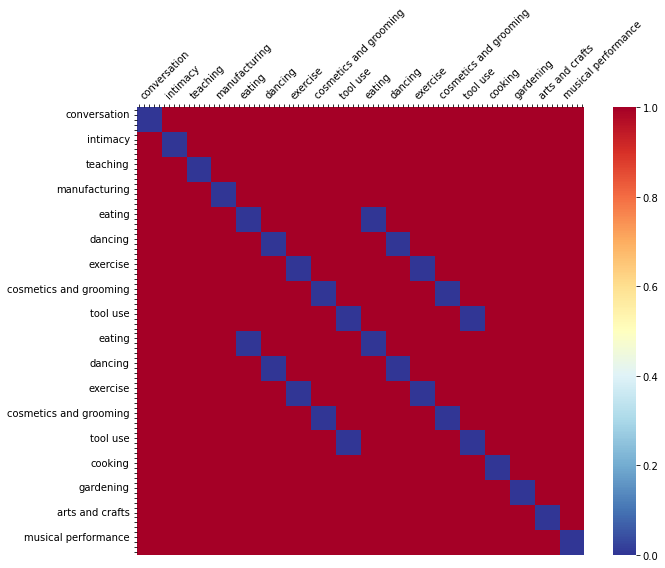

In [11]:
# category RDM quick check
plt.figure(figsize=(10, 8))
ax = sns.heatmap(squareform(actioncat_rdm)[reorder][:, reorder],
                 vmin=0, vmax=1, square=True, cmap='RdYlBu_r',
                 xticklabels=sparse_ordered_labels, yticklabels=sparse_ordered_labels)
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left'); plt.yticks(va='top')
plt.tight_layout(); plt.show()

In [15]:
# Compute Spearman correlations between target/model RDMs
def inter_model_correlations(model_rdms, model_names=None):
    if model_names:
        models_rdm = pdist([rankdata(model_rdms[name]) for name in model_names], 'correlation')
    elif not model_names:
        model_names = sorted(model_rdms.keys())
        models_rdm = pdist([rankdata(model_rdms[name]) for name in model_names], 'correlation')
    return models_rdm

In [16]:
# Plot correlation matrix funciton 
def plot_correlation_matrix(rdm, save_fn=None, **kwargs):
    ax = sns.heatmap(1 - squareform(rdm), square=True, annot=True,
                     cmap='RdYlBu_r', vmin=-1., vmax=1., fmt='.2f',
                     cbar_kws={'label': 'Spearman correlation'},
                     **kwargs)
    
    ax.xaxis.tick_top()
    plt.xticks(rotation=45, ha='left')
    
    cbar = ax.collections[0].colorbar
    cbar.set_label('Spearman correlation',
                   rotation=270)
    cbar.set_ticks([-1, -.5, 0, .5, 1.])
    #plt.xticks(rotation=45, ha='left')
    
    plt.tight_layout()
    if save_fn:
        plt.savefig(save_fn + '.svg', format='svg', transparent=True)
        plt.savefig(save_fn + '.png', format='png', dpi=300, transparent=True)
    else:
        plt.show()
    plt.close('all')

In [17]:
# Inter-model Spearman correlations
base_dir = '/backup/data/social_actions'
figures_dir = join(base_dir, 'figures')

models_rdm = inter_model_correlations(model_rdms, model_names)

plot_correlation_matrix(models_rdm, save_fn=join(figures_dir, 'inter_model_correlations-body-ppl-cat'),
                        xticklabels=model_names,
                        yticklabels=model_names)

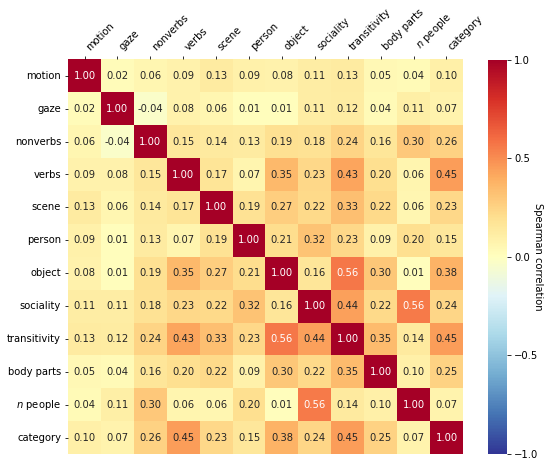

In [38]:
# plot inter-model matrix
def plot_intermodel_matrix(rdm, order=None, save_fn=None, **kwargs):
    
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(1 - squareform(rdm), square=True, annot=True,
                cmap='RdYlBu_r', vmin=-1., vmax=1., fmt='.2f',
                cbar_kws={'label': 'Spearman correlation', 'shrink': .892}, ax=ax,
                **kwargs)
    
    ax.xaxis.tick_top()
    plt.xticks(rotation=45, ha='left')
    
    cbar = ax.collections[0].colorbar
    cbar.set_label('Spearman correlation',
                   rotation=270)
    cbar.set_ticks([-1, -.5, 0, .5, 1.])
    #plt.xticks(rotation=45, ha='left')
    
    plt.tight_layout()
    if save_fn:
        plt.savefig(save_fn + '.svg', format='svg', transparent=True)
        plt.savefig(save_fn + '.png', format='png', dpi=300, transparent=True)
    else:
        plt.show()
    plt.close('all')

plot_intermodel_matrix(models_rdm, xticklabels=model_names, yticklabels=model_names)
plot_intermodel_matrix(models_rdm, save_fn='../../figures/inter_model_correlations-body-ppl-cat', xticklabels=model_names, yticklabels=model_names)

In [19]:
pwd

'/backup/data/social_actions/scripts/post_hha'

In [ ]:
# number of people RDM check

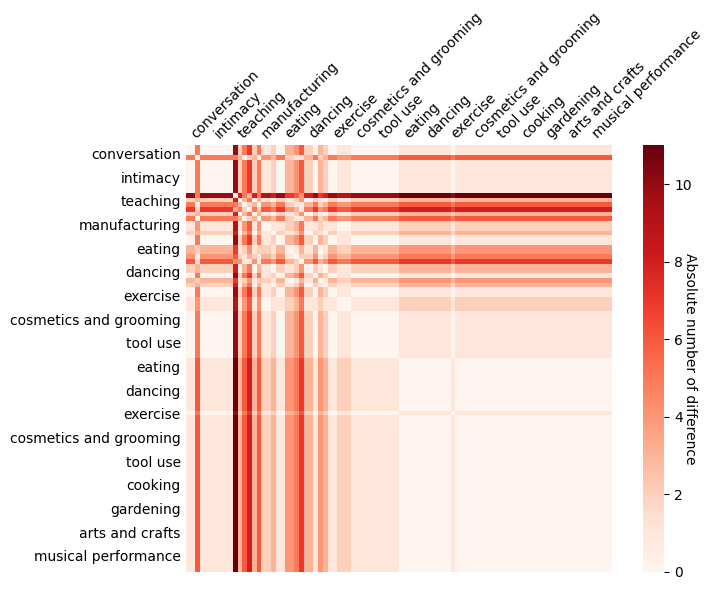

In [96]:
# plot ppl_rdm absolute number difference
plt.figure(figsize=(8, 6))
ax = sns.heatmap(squareform(ppl_rdm)[reorder][:, reorder],
            square=True, cmap='Reds', xticklabels=sparse_ordered_labels, yticklabels=sparse_ordered_labels)
ax.xaxis.tick_top()
ax.tick_params(axis='both', length=0) #no tick
plt.xticks(rotation=45, ha='left')
plt.yticks(va='top')
cbar = ax.collections[0].colorbar
cbar.set_label('Absolute number of difference',
                   rotation=270)
plt.tight_layout()

save_fn = 'ppl_rdm'
plt.savefig(save_fn + '.svg', format='svg', transparent=True)
plt.savefig(save_fn + '.png', format='png', dpi=300, transparent=True)

plt.show()

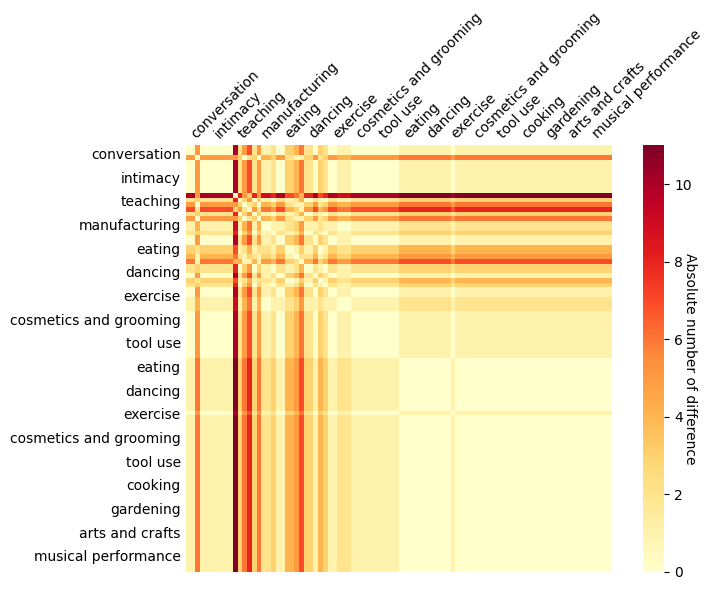

In [100]:
# plot ppl_rdm absolute number difference
# trying out other colors
plt.figure(figsize=(8, 6))
ax = sns.heatmap(squareform(ppl_rdm)[reorder][:, reorder],
            square=True, cmap='YlOrRd', xticklabels=sparse_ordered_labels, yticklabels=sparse_ordered_labels)
ax.xaxis.tick_top()
ax.tick_params(axis='both', length=0) #no tick
plt.xticks(rotation=45, ha='left')
plt.yticks(va='top')
cbar = ax.collections[0].colorbar
cbar.set_label('Absolute number of difference',
                   rotation=270)
plt.tight_layout()
'''
save_fn = 'ppl_rdm'
plt.savefig(save_fn + '.svg', format='svg', transparent=True)
plt.savefig(save_fn + '.png', format='png', dpi=300, transparent=True)
'''
plt.show()

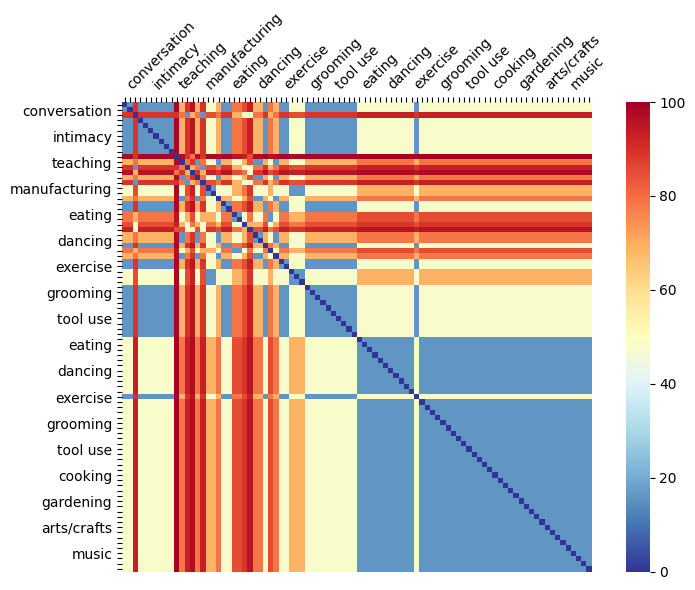

In [110]:
# plot ppl_rdm percentage
from scipy.stats import spearmanr
from os.path import join

reorder = [10, 11, 12, 13, 14, 65, 66, 67, 68, 69, 75, 76, 77, 78, 79,
           5, 6, 7, 8, 9, 40, 41, 42, 44, 45, 31, 32, 33, 34, 35,
           55, 56, 57, 58, 59, 25, 26, 27, 28, 29, 80, 81, 82, 83, 84,
           43, 46, 47, 48, 49, 30, 36, 37, 38, 39, 50, 51, 52, 53, 54,
           20, 21, 22, 23, 24, 85, 86, 87, 88, 89, 15, 16, 17, 18, 19,
           60, 61, 62, 63, 64, 0, 1, 2, 3, 4, 70, 71, 72, 73, 74]

sparse_ordered_labels = np.load(os.path.join(ha_dir,'sparse_ordered_labels.npy')).astype(str)
# truncated
sparse_ordered_labels[sparse_ordered_labels == 'cosmetics and grooming'] = 'grooming'
sparse_ordered_labels[sparse_ordered_labels == 'arts and crafts'] = 'arts/crafts'
sparse_ordered_labels[sparse_ordered_labels == 'musical performance'] = 'music'

plt.figure(figsize=(8, 6))
ax = sns.heatmap(squareform(rankdata(ppl_rdm) / len(ppl_rdm) * 100)[reorder][:, reorder], vmin=0, vmax=100,
            square=True, cmap='RdYlBu_r', xticklabels=sparse_ordered_labels, yticklabels=sparse_ordered_labels)
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
plt.yticks(va='top')
plt.tight_layout()
plt.show()

In [67]:
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

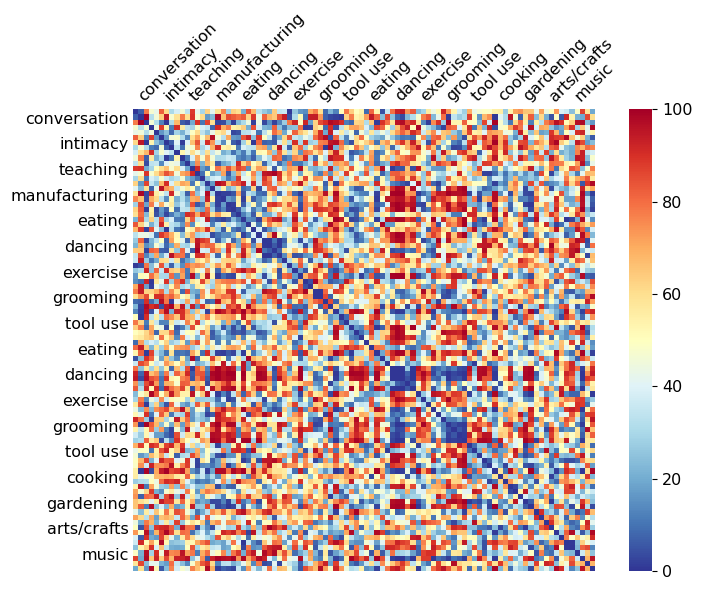

In [119]:
## check one rdm first 
# another sample
name = 'motion'
rdm = motion_rdm
font_size = 11.5

plt.rcParams['svg.fonttype'] = 'none' #text as texts not curves
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    squareform(rankdata(rdm) / len(rdm) * 100)[reorder][:, reorder],
    vmin=0, vmax=100,
    square=True,
    cmap='RdYlBu_r',
    xticklabels=sparse_ordered_labels,
    yticklabels=sparse_ordered_labels
)
ax.xaxis.tick_top()
ax.tick_params(axis='both', length=0)
for xt in ax.get_xticklabels():
    xt.set_fontsize(font_size)
for yt in ax.get_yticklabels():
    yt.set_fontsize(font_size)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=font_size)
plt.xticks(rotation=45, ha='left')
plt.yticks(va='top')
plt.tight_layout()

save_fn = f'{save_dir}/{name}_rdm_shortened'
plt.savefig(f'{save_fn}.svg', format='svg', transparent=True)
plt.savefig(f'{save_fn}.png', format='png', dpi=300, transparent=True)

plt.show()

In [23]:
## save RDMs
# Model RDMs dictionary
model_rdms = {
    'category': actioncat_rdm,
    'body': anno_rdm}

'''
model_rdms = {
    'motion': motion_rdm,
    'gaze': gaze_rdm,
    'verbs': verb_rdm,
    'nonverbs': nonverb_rdm,
    'transitivity': object_rdm,
    'sociality': social_rdm,
    'object': static_object_rdm,
    'scene': static_scene_rdm,
    'person': static_person_rdm,
    'people': ppl_rdm
}
'''
# Save directory (relative path)
save_dir = '../RDMs'
font_size = 11.5

# Loop through each RDM and plot
for name, rdm in model_rdms.items():
    plt.rcParams['svg.fonttype'] = 'none' #text as texts not curves
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        squareform(rankdata(rdm) / len(rdm) * 100)[reorder][:, reorder],
        vmin=0, vmax=100,
        square=True,
        cmap='RdYlBu_r',
        cbar=False, #easier handling
        xticklabels=sparse_ordered_labels,
        yticklabels=sparse_ordered_labels
    )
    ax.xaxis.tick_top()
    ax.tick_params(axis='both', length=0)
    for xt in ax.get_xticklabels():
        xt.set_fontsize(font_size)
    for yt in ax.get_yticklabels():
        yt.set_fontsize(font_size)
    #cbar = ax.collections[0].colorbar
    #cbar.ax.tick_params(labelsize=font_size)
    
    plt.xticks(rotation=45, ha='left')
    plt.yticks(va='top')
    plt.tight_layout()

    # Save
    save_fn = f'{save_dir}/{name}_rdm_shortened'
    plt.savefig(f'{save_fn}.svg', format='svg', transparent=True)
    plt.savefig(f'{save_fn}.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    plt.close()  # Close the plot to avoid memory issues

In [124]:
## draw and save K-means clusters RDMs

load_dir = '/home/nastase/actions-vt'
save_dir = '../RDMs'
font_size = 11.5

# Loop through each RDM and plot
for ncluster in range(1,5):
    for hemi in ['lh', 'rh']:
    
        #load
        npy_path = f'{load_dir}/vt_kmeans_k-4_cluster-{ncluster}_hemi-{hemi}_rdm.npy'
        rdm = np.load(npy_path)
        
        plt.rcParams['svg.fonttype'] = 'none' #text as texts not curves
        plt.figure(figsize=(8, 6))
        ax = sns.heatmap(
            squareform(rankdata(rdm) / len(rdm) * 100)[reorder][:, reorder],
            vmin=0, vmax=100,
            square=True,
            cmap='RdYlBu_r',
            cbar=False, #easier handling
            xticklabels=sparse_ordered_labels,
            yticklabels=sparse_ordered_labels
        )
        ax.xaxis.tick_top()
        ax.tick_params(axis='both', length=0)
        for xt in ax.get_xticklabels():
            xt.set_fontsize(font_size)
        for yt in ax.get_yticklabels():
            yt.set_fontsize(font_size)

        plt.xticks(rotation=45, ha='left')
        plt.yticks(va='top')
        plt.tight_layout()

        # Save
        save_fn = f'{save_dir}/vt_kmeans_k-4_cluster-{ncluster}_hemi-{hemi}_rdm'
        plt.savefig(f'{save_fn}.svg', format='svg', transparent=True)
        plt.savefig(f'{save_fn}.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
        print(f'Saved {save_fn} in .svg and .png')
        plt.close()  # Close the plot to avoid memory issues

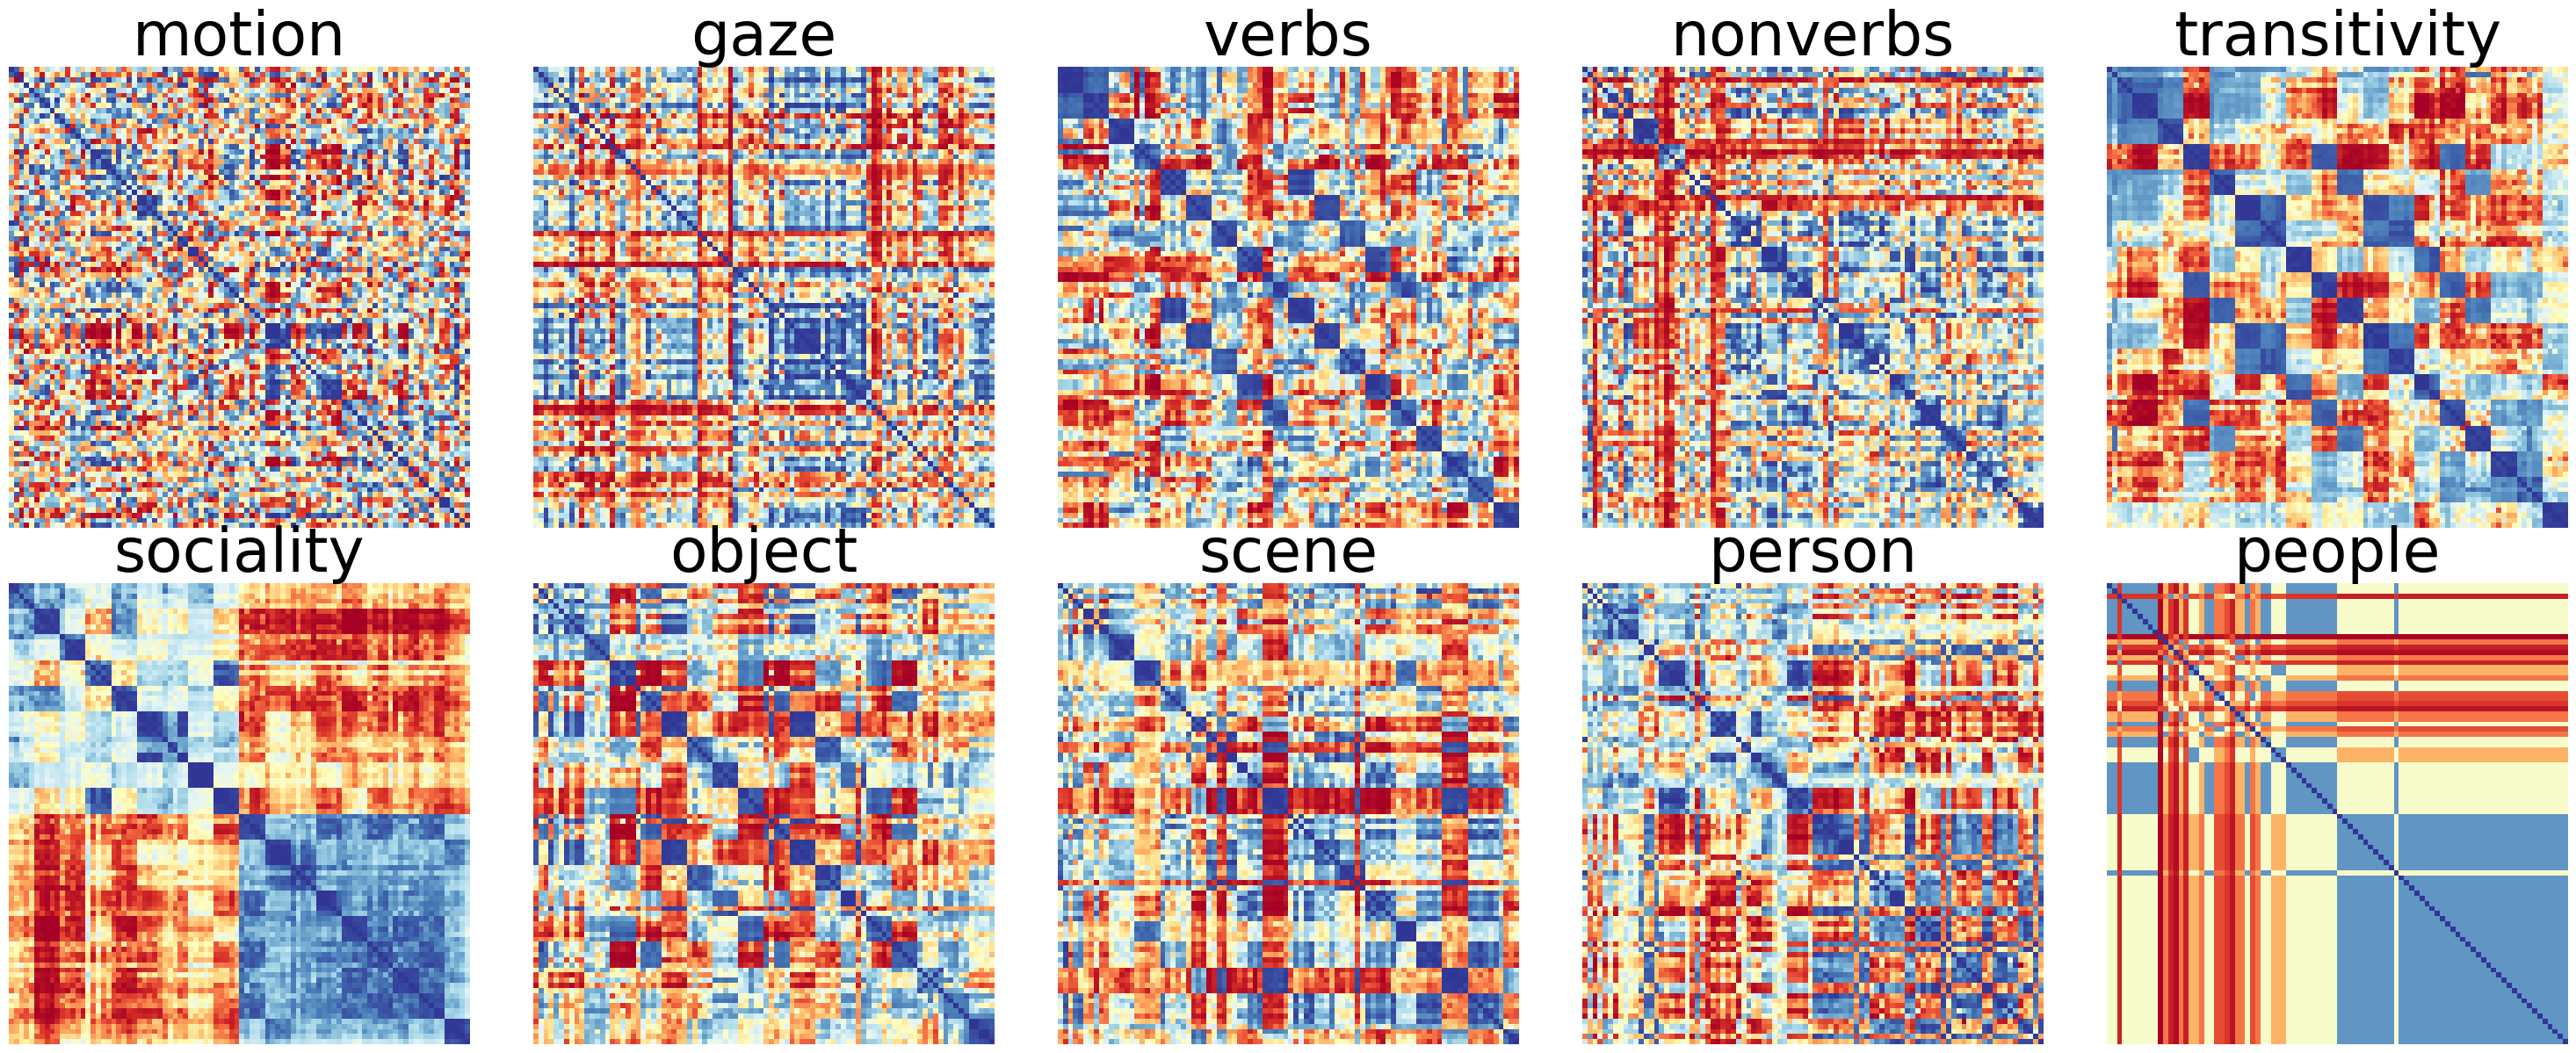

In [82]:
## show all RDMs in a 5x2 grid
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.stats import rankdata

n_rdms = len(model_rdms)
n_rows = 2
n_cols = (n_rdms + n_rows - 1) // n_rows  # Ceiling division


fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))

# Flatten in case axes is 2D
axes = axes.flatten()

for ax, (name, rdm) in zip(axes, model_rdms.items()):
    sns.heatmap(
        squareform(rankdata(rdm) / len(rdm) * 100)[reorder][:, reorder],
        vmin=0, vmax=100,
        square=True,
        cmap='RdYlBu_r',
        xticklabels=False,
        yticklabels=False,
        ax=ax,
        cbar=False
    )
    ax.set_title(name, fontsize=50, pad=10)
    ax.xaxis.tick_top()
    ax.tick_params(axis='both', length=0)

# Hide unused subplots
for i in range(len(model_rdms), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
fig.savefig('../RDMs/all_rdms_5x2_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# figure structure 
# S6 motion, gaze, 
# S7 nonverb, verb, 
# S8 scene, object, person, nPeople
# S9 sociality, transitivity  